# 04 — Real data: NGC 5102 HST/STIS galactic center

This notebook fits a spectrum of NGC 5102 from the Hubble Space Telescope using the
STIS spectrograph (G750L grating).  The STIS data has higher spatial resolution than
MUSE (~0.1 arcsec per bin vs ~0.2 arcsec), which probes kinematics at smaller radii.

The spectrum used here (`bin0105sp.spec`) is a spatial bin from the inner region of
the galaxy.  The data is bundled in `examples/data/stis/`.

**Key differences from the MUSE notebook:**
- Shorter wavelength range (8275 – 8846 Å, step = 0.5586 Å/pixel)
- The file's error column is a placeholder, not real per-pixel errors — we override
  it with a uniform S/N-based estimate (`gal_errors=flux/50`), same approach as the
  MUSE notebook, rather than using `use_spectrum_errors=True`
- Templates are CaT stellar library scans (Cenarro et al. 2001)
- `wavemin_full` and `step` must be provided because the spectrum file uses integer pixel indices

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit
from kinextract.fitting import fit_losvd_gauss_hermite


# Path to bundled example data (adjust if running from a different location)
DATA_DIR = Path('..') / 'data'
STIS_DIR = DATA_DIR / 'stis'

# ── To use a different spectrum, change this line ────────────────────────────
SPEC_FILE = STIS_DIR / 'bin0105sp.spec'

## 1. Load and inspect the spectrum

In [2]:
# ── STIS wavelength grid ──────────────────────────────────────────────────────
# The .spec file contains integer pixel indices (1–1024); kinextract reconstructs
# wavelengths as: wave = wavemin_full + (pix - 1) * step
WAVEMIN_FULL = 8275.0       # Å, pixel 1
STEP         = 0.5586       # Å / pixel  (mean STIS G750L dispersion)
N_PIX        = 1024
wavelength   = WAVEMIN_FULL + np.arange(N_PIX) * STEP   # observed frame

data = np.loadtxt(SPEC_FILE)
pix, flux = data[:, 0].astype(int), data[:, 1]

# This STIS spectrum just has placeholder error values, 
# so we can use a simple S/N estimate to set the errors instead
snr = 50.0
ferr = (flux / snr) + 1e-3  # counts, avoid zero error

print(f"Spectrum pixels: {len(flux)}")
print(f"Flux range:  {flux.min():.0f} - {flux.max():.0f}  counts")
print(f"Error range: {ferr.min():.0f} - {ferr.max():.0f}  counts")
print(f"Median S/N per pixel: {np.median(flux / ferr):.1f}")

Spectrum pixels: 1024
Flux range:  0 - 12996374  counts
Error range: 0 - 259927  counts
Median S/N per pixel: 50.0


## 2. Quick-look plot

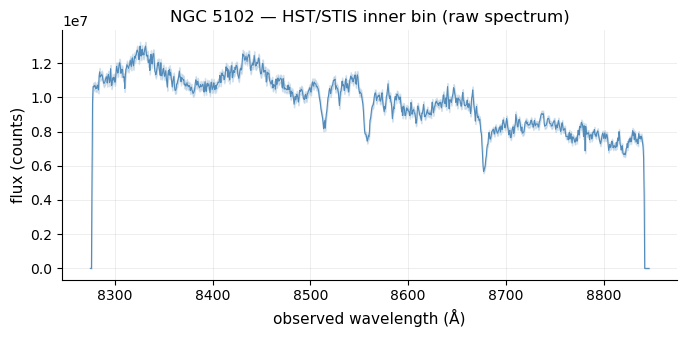

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wavelength, flux, lw=0.8, color='steelblue', alpha=0.9)
ax.fill_between(wavelength, flux - ferr, flux + ferr, color='steelblue', alpha=0.2)
ax.set_xlabel('observed wavelength (Å)')
ax.set_ylabel('flux (counts)')
ax.set_title('NGC 5102 — HST/STIS inner bin (raw spectrum)')
plt.tight_layout()
plt.show()

## 3. FitConfig for STIS

Because column 0 of the `.spec` file contains integer pixel indices, kinextract
needs `wavemin_full` and `step` to reconstruct the wavelength axis.

The file's own error column is just a placeholder, so we pass the S/N-based `ferr`
computed above directly via `gal_errors=` (overriding the file column) and set
`use_spectrum_errors=False` since we're not using the file's errors either way.

In [4]:

cfg = FitConfig(
    template_list_file    = str(STIS_DIR / 'Tlist'),
    template_dir          = str(STIS_DIR),
    # outdir="./my_output_dir", write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full          = WAVEMIN_FULL,  # Å, minimum wavelength of full spectrum (pixel 1)
    step                  = STEP,          # Å / pixel
    wavefitmin            = 8400.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8750.0,        # Å
    zgal                  = 0.001556,      # redshift estimate from NED (heliocentric)
    losvd_vmin            = -300.0,        # km/s
    losvd_vmax            = +300.0,        # km/s
    fit_als_continuum     = True,
    als_optimize          = True,          # Optimize ALS hyperparameters (λ, p) using BIC
    als_use_bic           = True,
    als_bic_dof_penalty   = 1.0,           # BIC penalty factor for LOSVD degrees of freedom
    use_spectrum_errors   = False,         # per-pixel errors not available
    xlam_auto             = True,
    xlam_criterion        = 'roughness',   # Allows us to control how smooth the LOSVD is; 'roughness' is a good default for real data
    xlam_smooth_threshold = 0.20,          # Controls how smooth the LOSVD is; smaller = smoother. Default is 0.25.
    sigl                  = 100.0,
    clean                 = True,
    clean_ca_half_width   = 8.0,
    map_maxiter           = 2000,
    print_every           = 10000,
)
print("FitConfig ready.")

FitConfig ready.


## 4. Run the fit

In [5]:
# Initial fit with the S/N-based error guess from above, then one
# error-rescaling pass: per-pixel errors this simple are a placeholder, not
# a validated noise model, so we calibrate their overall scale against the
# fit itself (rescale by sqrt(chi2_red), refit) -- standard practice for
# LOSVD fitting, rather than reporting chi2_red far from 1 at face value.
fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
scale = float(np.sqrt(fit['outputs']['chi2_red']))
ferr = ferr * scale
print(f"Error rescaling: chi2_red={fit['outputs']['chi2_red']:.3f} -> scale factor {scale:.3f} -> refitting")

fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chi2_red = {out['chi2_red']:.3f}  (after error rescaling)")
print(f"xlam used = {st.xlam}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

[     0.86s] ==== spectral fitting START | ../data/stis/bin0105sp.spec ====


[     0.86s] wavefit=[8400.0, 8750.0] z=0.001556 sigl=100.0 xlam=300.0


[     0.86s] fit_als_continuum=True prenorm=False


[     0.86s] START build FitState


[     0.86s] START read spectrum


...

[     4.23s] START MAP final after ALS continuum update


[     4.34s] END   MAP final after ALS continuum update (0.11s)


[     4.34s] Final chi2=632.787 ngood=622 xlam=100.0


[     4.34s] ==== spectral fitting END ====


chi2_red = 1.019  (after error rescaling)
xlam used = 100.0
success     : True


In [6]:
from IPython.display import display, Math

display(Math(fr"\chi^2_{{\rm red}} = {out['chi2_red']:.3f}"))

<IPython.core.display.Math object>

## 5. Gauss-Hermite moments

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V  = {gh['vherm']:+.1f} km/s")
print(f"σ  = {gh['sherm']:.1f} km/s")
print(f"h3 = {gh['h3']:+.4f}")
print(f"h4 = {gh['h4']:+.4f}")

V  = +14.2 km/s
σ  = 63.9 km/s
h3 = +0.1412
h4 = +0.0667


## 6. Results plots

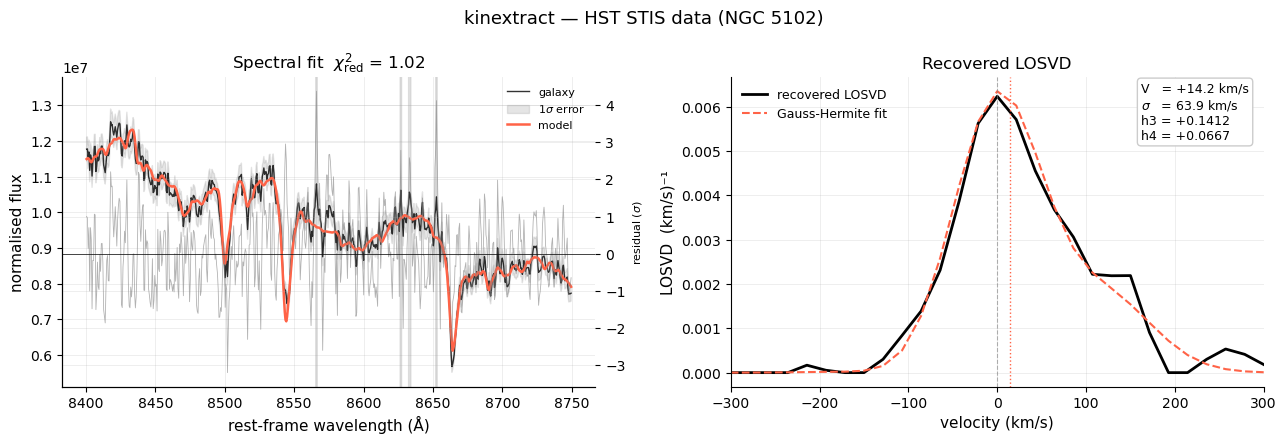

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — HST STIS data (NGC 5102)', fontsize=13)

# ── Panel 1: spectral fit ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.fill_between(st.x, st.g - st.gerr, st.g + st.gerr, alpha=0.20, color='gray', label=r'$1\sigma$ error')
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax.set_ylim(0.9*st.g.min(), 1.1*st.g.max())
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel('rest-frame wavelength (Å)')
ax.set_ylabel('normalised flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
b_norm = b / trapezoid(b, st.xl)
ax.plot(st.xl, b_norm, lw=2.0, color='black', label='recovered LOSVD')
ax.plot(st.xl, gh['model']/trapezoid(gh['model'], st.xl), lw=1.5, color='tomato', ls='--', label='Gauss-Hermite fit')
ax.axvline(gh['vherm'], lw=1.0, color='tomato', ls=':')
ax.axvline(0,           lw=0.8, color='grey',   ls='--', alpha=0.6)
ax.text(0.77, 0.79,
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s\n"
        f"h3 = {gh['h3']:+.4f}\n"
        f"h4 = {gh['h4']:+.4f}",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 7. Error estimation

Uncertainty on the LOSVD is estimated two complementary ways:

- **Laplace / penalized-likelihood covariance** (fast, ~seconds): inverts a finite-difference Hessian of the MAP objective at the best-fit solution to get an approximate posterior covariance. Cheap and always worth running first, but likely underestimates true errors if the noise model or regularization strength is imperfect.
- **Residual bootstrap** (more thorough, slower): resamples fit residuals into synthetic spectra and refits each through the same MAP machinery -> an independent, frequentist cross-check that doesn't rely on the Laplace approximation. Slower since each of N_BOOT replicates is a full refit.

In [9]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
laplace = est.laplace_covariance()
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=1)
summary = est.summarize(laplace_result=laplace, bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Recommended uncertainties (bootstrap preferred over Laplace when both available):")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Computing Hessian...
[LOSVDErrors] Using JAX gradient-backed Hessian FD (CPU)


[LOSVDErrors] Laplace covariance done in 0.4s. Hessian PD (free params): True. Pinned: 8/29 LOSVD bins, 1/1 template weights. Max projected |grad|: 0.352
[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=1)...
[     5.07s] Ca II mask shift: +2.433 Å  (als_mask_center_shift_A → 7.045 Å)


[     5.08s] ALS absorption-clean iter 1: sigma=1.258, rejected=0, base_pixels=537


[     5.08s] ALS init: lam=1.000e+03 p=0.05 median=9.334e+06 base_pixels=537 line_mask_pixels=85


[     5.08s] ALS outer iteration 1/4


...

[   117.13s]   ALS continuum median fractional change = 0.04202


[   117.13s] Final MAP refit with final ALS continuum fixed


[   117.13s] START MAP final after ALS continuum update


[   117.46s] END   MAP final after ALS continuum update (0.33s)


[LOSVDErrors] Bootstrap 50/50 (112s elapsed)
[LOSVDErrors] Bootstrap done in 112.4s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +14.22 km/s ± 4.38
    σ    = 63.89 km/s ± 10.41
    h3   = +0.1412 ± 0.0627
    h4   = +0.0667 ± 0.0531
  LOSVD moments (for reference):
    V    = +18.71 km/s ± 6.81
    σ    = 42.49 km/s ± 14.14

  Bootstrap: 50 successful / 50 total replicates

Recommended uncertainties (bootstrap preferred over Laplace when both available):
  V     = +14.22 km/s ± 4.38
  σ     = +63.89 km/s ± 10.41
  h3    = +0.14 ± 0.06
  h4    = +0.07 ± 0.05


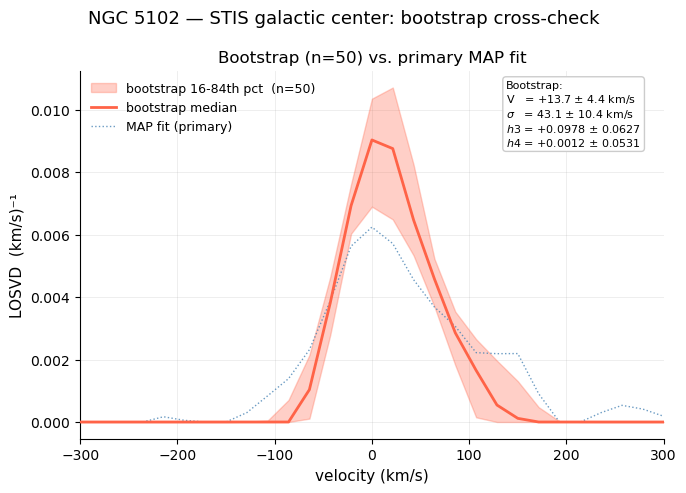

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('NGC 5102 — STIS galactic center: bootstrap cross-check', fontsize=13)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

bs       = np.array(boot['b_samples'])
bs_traps = np.array([trapezoid(s, st.xl) for s in bs])[:, np.newaxis]
bs       = bs / bs_traps
b_median = np.median(bs, axis=0)
b_lo     = np.maximum(np.percentile(bs, 16, axis=0), 0.0)
b_hi     = np.percentile(bs, 84, axis=0)
gh_med   = fit_losvd_gauss_hermite(st.xl, b_median, fit_h3h4=True)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap 16-84th pct  (n={N_BOOT})')
ax.plot(st.xl, b_median, lw=2.0, color='tomato', zorder=5, label='bootstrap median')
ax.plot(st.xl, b_norm, lw=1.0, ls=':', color='steelblue', alpha=0.8, label='MAP fit (primary)')

ax.text(0.73, 0.79,
        f"Bootstrap:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'Bootstrap (n={N_BOOT}) vs. primary MAP fit')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()